In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.feature_extraction.text import CountVectorizer

In [2]:
df = pd.read_csv(r"E:\ML\data\fake_email.csv")

In [3]:
df.head()

,email_text,label
0,Urgent! Your bank account will be suspended. C...,fake
1,You won a lottery of $500000. Send your detail...,fake
2,Confirm your password to avoid account closure.,fake
3,Claim your free gift card by clicking this link.,fake
4,Your package is on hold. Pay a small fee to re...,fake


<Axes: xlabel='count', ylabel='label'>

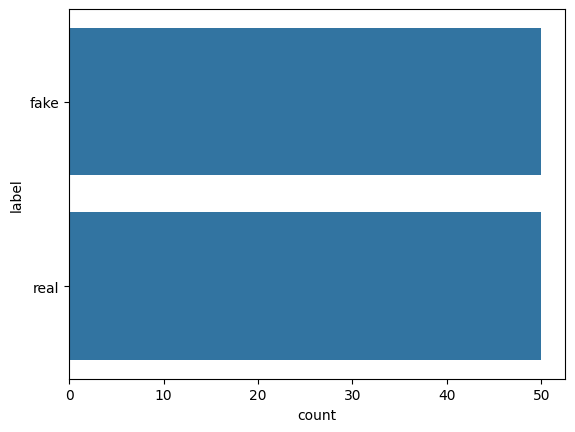

In [4]:
sns.countplot(
    df['label']
)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   email_text  100 non-null    object
 1   label       100 non-null    object
dtypes: object(2)
memory usage: 1.7+ KB


In [6]:
df.isnull().sum()

email_text    0
label         0
dtype: int64

In [7]:
X = df["email_text"]
y = df['label']

In [8]:
X

0     Urgent! Your bank account will be suspended. C...
1     You won a lottery of $500000. Send your detail...
2       Confirm your password to avoid account closure.
3      Claim your free gift card by clicking this link.
4     Your package is on hold. Pay a small fee to re...
                            ...                        
95       Reminder about the training session on Friday.
96    Your order has been shipped and will arrive soon.
97       Please review the document and share feedback.
98    Welcome to our company. We are excited to have...
99    Your subscription renewal has been processed s...
Name: email_text, Length: 100, dtype: object

In [9]:
y

0     fake
1     fake
2     fake
3     fake
4     fake
      ... 
95    real
96    real
97    real
98    real
99    real
Name: label, Length: 100, dtype: object

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size=0.2,
    random_state=42,
)

In [11]:
X_train

55       Reminder about the training session on Friday.
88    Welcome to our company. We are excited to have...
26    Security alert: Login attempt detected. Verify...
42      Confirm your password to avoid account closure.
69    Your subscription renewal has been processed s...
                            ...                        
60          Team meeting scheduled for Monday at 10 AM.
71       Please find the attached monthly sales report.
14    Your package is on hold. Pay a small fee to re...
92            Your interview is confirmed for tomorrow.
51       Please find the attached monthly sales report.
Name: email_text, Length: 80, dtype: object

In [12]:
y_train

55    real
88    real
26    fake
42    fake
69    real
      ... 
60    real
71    real
14    fake
92    real
51    real
Name: label, Length: 80, dtype: object

In [13]:
ve = CountVectorizer()
X_train = ve.fit_transform(X_train)
X_test = ve.transform(X_test)

In [14]:
X_test

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 176 stored elements and shape (20, 116)>

In [15]:
model = MultinomialNB()
model.fit(X_train, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [16]:
pred = model.predict(X_test)

In [17]:
print(pred)

['real' 'real' 'real' 'fake' 'fake' 'fake' 'fake' 'real' 'fake' 'fake'
 'fake' 'fake' 'real' 'fake' 'real' 'fake' 'real' 'real' 'fake' 'fake']


In [18]:
print("accuracy_score: ", accuracy_score(y_test, pred))

accuracy_score:  1.0


In [24]:
new = [
    "you have been declared won an iphone"
]

new_ve = ve.transform(new)
y_pred = model.predict(new_ve)
print("prediction: ", y_pred)

prediction:  ['fake']
